In [20]:
import os
import random
import warnings

import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

from PIL import Image

warnings.filterwarnings("ignore")

In [21]:
dataset_path = kagglehub.dataset_download(
    "zaidpy/oral-cancer-dataset"
)

print("Dataset path:", dataset_path)

Dataset path: C:\Users\Naveen Singh Rawat\.cache\kagglehub\datasets\zaidpy\oral-cancer-dataset\versions\2


In [14]:
for root, dirs, files in os.walk(dataset_path):
    print(root)
    print("Images:", len(files))

E:\PROJECTS\OralScan-AI\dataset
Images: 0
E:\PROJECTS\OralScan-AI\dataset\processed
Images: 0
E:\PROJECTS\OralScan-AI\dataset\processed\test
Images: 0
E:\PROJECTS\OralScan-AI\dataset\processed\test\normal
Images: 0
E:\PROJECTS\OralScan-AI\dataset\processed\test\precancerous
Images: 0
E:\PROJECTS\OralScan-AI\dataset\processed\test\suspicious
Images: 0
E:\PROJECTS\OralScan-AI\dataset\processed\train
Images: 0
E:\PROJECTS\OralScan-AI\dataset\processed\train\normal
Images: 0
E:\PROJECTS\OralScan-AI\dataset\processed\train\precancerous
Images: 0
E:\PROJECTS\OralScan-AI\dataset\processed\train\suspicious
Images: 0
E:\PROJECTS\OralScan-AI\dataset\processed\validation
Images: 0
E:\PROJECTS\OralScan-AI\dataset\processed\validation\normal
Images: 0
E:\PROJECTS\OralScan-AI\dataset\processed\validation\precancerous
Images: 0
E:\PROJECTS\OralScan-AI\dataset\processed\validation\suspicious
Images: 0
E:\PROJECTS\OralScan-AI\dataset\raw
Images: 0


In [22]:
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, "").count(os.sep)
    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")
    print(f"{indent}Images: {len(files)}")

2/
Images: 0
    Oral Cancer/
    Images: 0
        Oral Cancer Dataset/
        Images: 0
            CANCER/
            Images: 500
            NON CANCER/
            Images: 250
    Oral cancer Dataset 2.0/
    Images: 0
        OC Dataset kaggle new/
        Images: 0
            CANCER/
            Images: 500
            NON CANCER/
            Images: 450


In [23]:
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

image_folders = []

for root, dirs, files in os.walk(dataset_path):
    image_files = [
        file for file in files
        if file.lower().endswith(IMAGE_EXTENSIONS)
    ]

    if image_files:
        image_folders.append(root)

print("Image folders found:")

for folder in image_folders:
    print(folder)

Image folders found:
C:\Users\Naveen Singh Rawat\.cache\kagglehub\datasets\zaidpy\oral-cancer-dataset\versions\2\Oral Cancer\Oral Cancer Dataset\CANCER
C:\Users\Naveen Singh Rawat\.cache\kagglehub\datasets\zaidpy\oral-cancer-dataset\versions\2\Oral Cancer\Oral Cancer Dataset\NON CANCER
C:\Users\Naveen Singh Rawat\.cache\kagglehub\datasets\zaidpy\oral-cancer-dataset\versions\2\Oral cancer Dataset 2.0\OC Dataset kaggle new\CANCER
C:\Users\Naveen Singh Rawat\.cache\kagglehub\datasets\zaidpy\oral-cancer-dataset\versions\2\Oral cancer Dataset 2.0\OC Dataset kaggle new\NON CANCER


In [24]:
class_folders = {}

for folder in image_folders:
    class_name = os.path.basename(folder)
    class_folders[class_name] = folder

classes = list(class_folders.keys())

print("Classes:", classes)

Classes: ['CANCER', 'NON CANCER']


In [25]:
class_counts = {}

for class_name, folder in class_folders.items():
    image_files = [
        file for file in os.listdir(folder)
        if file.lower().endswith(IMAGE_EXTENSIONS)
    ]

    class_counts[class_name] = len(image_files)

for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

CANCER: 500
NON CANCER: 450


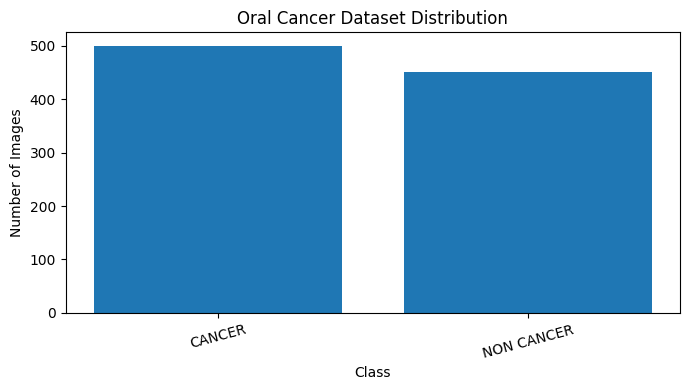

In [26]:
plt.figure(figsize=(7, 4))

plt.bar(
    class_counts.keys(),
    class_counts.values()
)

plt.title("Oral Cancer Dataset Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

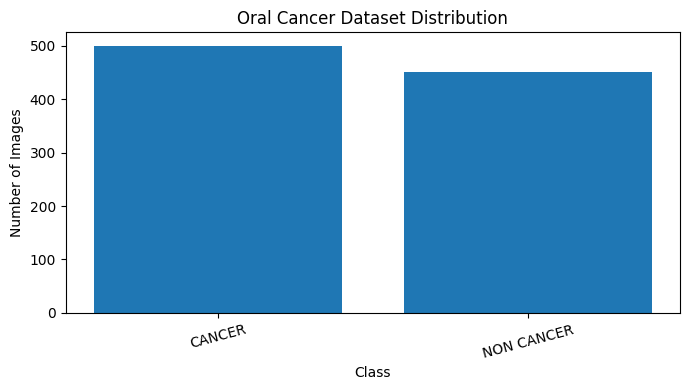

In [27]:
plt.figure(figsize=(7, 4))

plt.bar(
    class_counts.keys(),
    class_counts.values()
)

plt.title("Oral Cancer Dataset Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

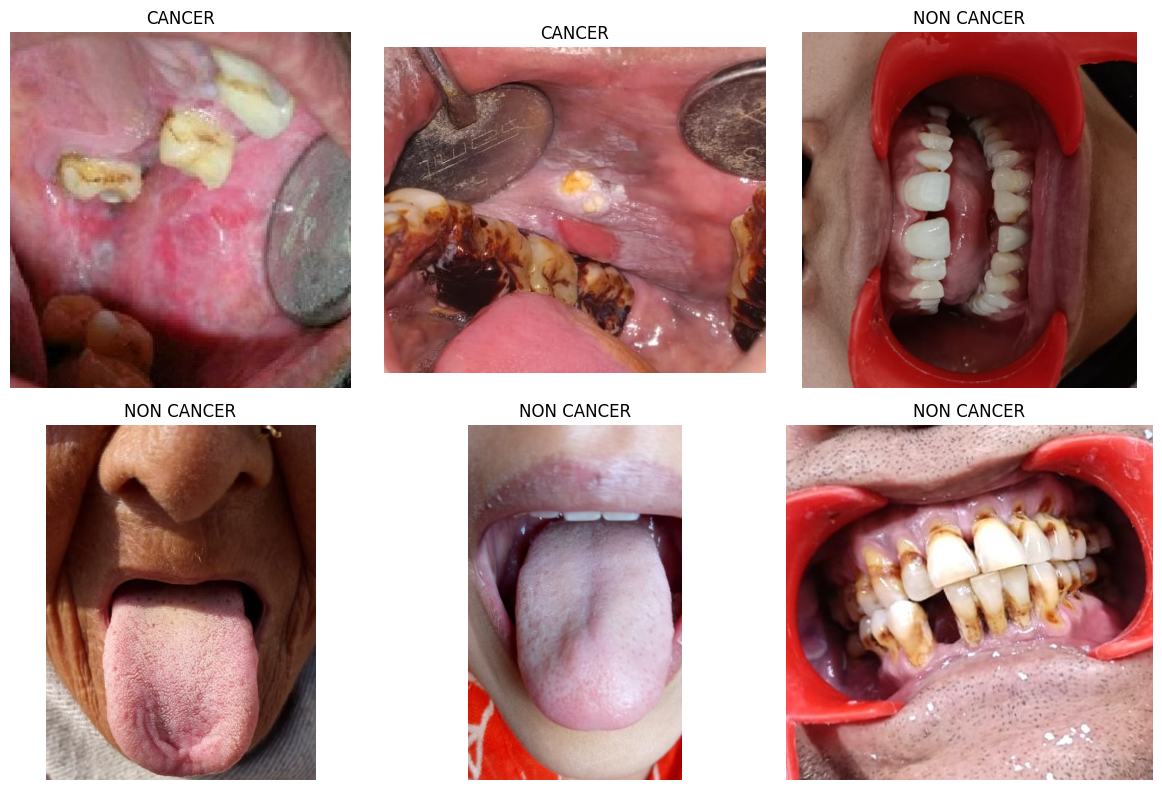

In [28]:
plt.figure(figsize=(12, 8))

for index in range(6):
    class_name = random.choice(classes)
    folder = class_folders[class_name]

    image_files = [
        file for file in os.listdir(folder)
        if file.lower().endswith(IMAGE_EXTENSIONS)
    ]

    image_name = random.choice(image_files)
    image_path = os.path.join(folder, image_name)

    with Image.open(image_path) as image:
        image = image.convert("RGB")

        plt.subplot(2, 3, index + 1)
        plt.imshow(image)
        plt.title(class_name)
        plt.axis("off")

plt.tight_layout()
plt.show()

In [29]:
image_records = []

for class_name, folder in class_folders.items():

    for image_name in os.listdir(folder):

        if not image_name.lower().endswith(IMAGE_EXTENSIONS):
            continue

        image_path = os.path.join(folder, image_name)

        try:
            with Image.open(image_path) as image:
                width, height = image.size

            image_records.append({
                "class": class_name,
                "filename": image_name,
                "width": width,
                "height": height
            })

        except Exception:
            pass

image_df = pd.DataFrame(image_records)

image_df.head()

,class,filename,width,height
0,CANCER,001.jpeg,280,205
1,CANCER,002.jpeg,280,205
2,CANCER,003.jpeg,280,205
3,CANCER,004.jpeg,280,205
4,CANCER,005.jpeg,1200,810


In [30]:
image_df[["width", "height"]].value_counts().head(10)

width  height
280    205       30
960    1280      28
468    1040      18
720    1280      13
275    183       10
1800   4000      10
1280   1280       5
720    415        4
274    184        4
225    225        4
Name: count, dtype: int64

In [31]:
image_df[["width", "height"]].describe()

,width,height
count,940.000000,940.000000
mean,694.675532,715.735106
std,698.248339,750.703937
min,90.000000,89.000000
25%,308.000000,269.750000
50%,485.000000,492.500000
75%,774.000000,822.000000
max,9248.000000,6936.000000


In [32]:
bad_images = []

for class_name, folder in class_folders.items():

    for image_name in os.listdir(folder):

        if not image_name.lower().endswith(IMAGE_EXTENSIONS):
            continue

        image_path = os.path.join(folder, image_name)

        try:
            with Image.open(image_path) as image:
                image.verify()

        except Exception as error:
            bad_images.append({
                "class": class_name,
                "filename": image_name,
                "path": image_path,
                "error": str(error)
            })

print("Corrupted images:", len(bad_images))

Corrupted images: 10


In [33]:
pd.DataFrame(bad_images)

,class,filename,path,error
0,CANCER,101.jpeg,C:\Users\Naveen Singh Rawat\.cache\kagglehub\d...,cannot identify image file 'C:\\Users\\Naveen ...
1,CANCER,200.jpeg,C:\Users\Naveen Singh Rawat\.cache\kagglehub\d...,cannot identify image file 'C:\\Users\\Naveen ...
2,CANCER,273.jpeg,C:\Users\Naveen Singh Rawat\.cache\kagglehub\d...,cannot identify image file 'C:\\Users\\Naveen ...
3,CANCER,317.jpeg,C:\Users\Naveen Singh Rawat\.cache\kagglehub\d...,cannot identify image file 'C:\\Users\\Naveen ...
4,CANCER,328.jpeg,C:\Users\Naveen Singh Rawat\.cache\kagglehub\d...,cannot identify image file 'C:\\Users\\Naveen ...
5,CANCER,407.jpeg,C:\Users\Naveen Singh Rawat\.cache\kagglehub\d...,cannot identify image file 'C:\\Users\\Naveen ...
6,CANCER,450.jpeg,C:\Users\Naveen Singh Rawat\.cache\kagglehub\d...,cannot identify image file 'C:\\Users\\Naveen ...
7,CANCER,455.jpeg,C:\Users\Naveen Singh Rawat\.cache\kagglehub\d...,cannot identify image file 'C:\\Users\\Naveen ...
8,CANCER,481.jpeg,C:\Users\Naveen Singh Rawat\.cache\kagglehub\d...,cannot identify image file 'C:\\Users\\Naveen ...
9,CANCER,485.jpeg,C:\Users\Naveen Singh Rawat\.cache\kagglehub\d...,cannot identify image file 'C:\\Users\\Naveen ...


In [34]:
print("=" * 45)
print("ORAL CANCER DATASET SUMMARY")
print("=" * 45)

print("Classes:", classes)
print("Number of classes:", len(classes))
print("Total valid images:", len(image_df))
print("Corrupted images:", len(bad_images))

print("\nImages per class:")

for class_name, count in class_counts.items():
    percentage = count / sum(class_counts.values()) * 100

    print(
        f"{class_name}: {count} images "
        f"({percentage:.2f}%)"
    )

ORAL CANCER DATASET SUMMARY
Classes: ['CANCER', 'NON CANCER']
Number of classes: 2
Total valid images: 940
Corrupted images: 10

Images per class:
CANCER: 500 images (52.63%)
NON CANCER: 450 images (47.37%)
